# A escada da recuperação na Web — da API ao Selenium

> **Versão LOCAL** (para rodar fora do Google Colab): grava numa pasta local e abre o navegador em janela visível. Para a versão do Colab, use o outro notebook.###  · Recuperação de Informação na Web e Mídias Sociais

Na **aula anterior**, a ISO voltou vazia: o scraper estático recebia só a casca de HTML, porque o texto era injetado por JavaScript. Aquilo deixou uma pergunta no ar — *e quando o conteúdo só existe depois do JavaScript rodar?*
Esta aula responde. Mas com uma reviravolta: antes de chegar ao Selenium, quase sempre a resposta certa é a API.

Diante de qualquer dado na Web, percorra os degraus **de cima para baixo** e pare no primeiro que resolve:

| Degrau | Abordagem | Quando usar |

|---|---|---|

|**1** | **API oficial** | Sempre que existir. Estruturada, estável, permitida. |

| **2** | **Dados abertos** | Arquivos prontos (CSV/JSON/OData) que o site já oferece. |

| **3** | **Scraping estático** | Conteúdo no HTML, sem API. |

| **4** | **Scraping dinâmico** | Último recurso: JavaScript ou interação obrigatória. |

> **Regra de ouro:** subir um degrau desnecessário — raspar o que tem API — é o anti-padrão que esta aula combate.

---# Degrau 1 — A API oficial do Banco CentralO dado econômico do nosso caso (câmbio, Focus) está disponível por **API pública**: a plataforma **Olinda / OData** do Banco Central. Nenhum scraping é necessário. Vamos recuperar a cotação do dólar (PTAX) direto da API.

Repare: **JSON estruturado, sem navegador, sem BeautifulSoup.**

Documentação: https://dadosabertos.bcb.gov.br/dataset/dolar-americano-usd-todos-os-boletins-diarios/resource/472f1280-edb1-4cc2-ba36-7bfdd04c1fef?inner_span=True

In [1]:
# === Versao LOCAL (sem Google Colab) ===
# Em vez de montar o Google Drive, gravamos numa pasta local, ao lado
# do notebook. A pasta e criada automaticamente se nao existir.
import os

PATH = "./dataset_economia_scraping/"
os.makedirs(PATH, exist_ok=True)
print(f'Saidas serao gravadas em: {os.path.abspath(PATH)}')

Saidas serao gravadas em: c:\Users\leonardo.flores\Desktop\UFOP\Recuperação da Informação na Web e Redes Sociais\A5\escada_recuperacao_LOCAL\dataset_economia_scraping


In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# API Olinda do Banco Central — cotacao diaria do dolar (PTAX)
# Documentacao: https://dadosabertos.bcb.gov.br/  (degrau 2: dados abertos documentados)

def cotacao_dolar_periodo(dias=400):
    """Recupera a cotacao do dolar dos ultimos N dias via API do BC.

    Coletamos MAIS DE UM ANO (padrao: 400 dias) para que o grafico
    temporal mostre tendencia e volatilidade reais do cambio -- nao
    apenas o ruido de poucos dias.
    """
    fim = datetime.now()
    ini = fim - timedelta(days=dias)
    base = ('https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/'
            'CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)')
    params = {
        '@dataInicial': f"'{ini.strftime('%m-%d-%Y')}'",
        '@dataFinalCotacao': f"'{fim.strftime('%m-%d-%Y')}'",
        '$format': 'json',
        '$select': 'cotacaoCompra,cotacaoVenda,dataHoraCotacao',
    }
    resp = requests.get(base, params=params, timeout=30)
    resp.raise_for_status()
    dados = resp.json().get('value', [])
    df = pd.DataFrame(dados)
    df['dataHoraCotacao'] = pd.to_datetime(df['dataHoraCotacao'])
    return df.sort_values('dataHoraCotacao').reset_index(drop=True)

df_dolar = cotacao_dolar_periodo(400)   # ~13 meses de cotacoes
print(f'{len(df_dolar)} cotacoes recuperadas via API (sem scraping).')
print(f'Periodo: {df_dolar["dataHoraCotacao"].min():%d/%m/%Y} '
      f'a {df_dolar["dataHoraCotacao"].max():%d/%m/%Y}')
df_dolar.tail()

277 cotacoes recuperadas via API (sem scraping).
Periodo: 04/06/2025 a 09/07/2026


,cotacaoCompra,cotacaoVenda,dataHoraCotacao
272,5.1711,5.1717,2026-07-03 13:08:41.147385
273,5.1664,5.1670,2026-07-06 13:10:16.255475
274,5.1452,5.1458,2026-07-07 13:06:24.657124
275,5.1546,5.1552,2026-07-08 13:04:28.047960
276,5.1323,5.1329,2026-07-09 13:04:17.610813


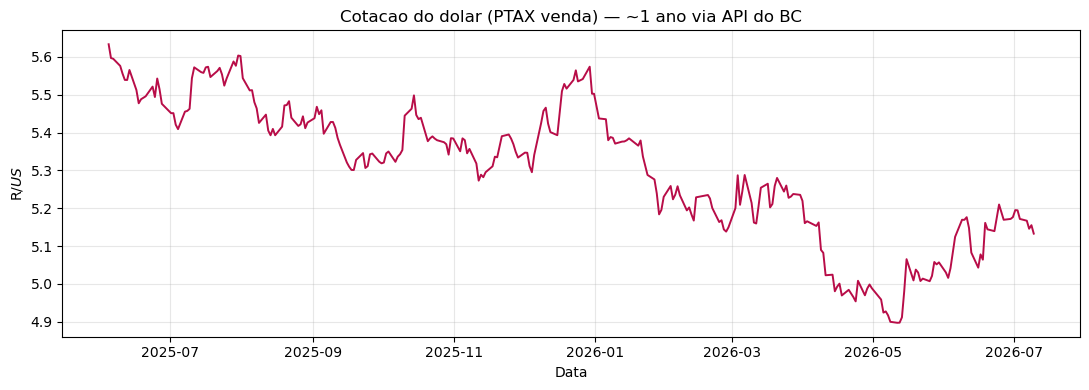

In [3]:
# Grafico temporal: visualiza a aplicacao do dado coletado (mais de 1 ano).
# Mostramos a cotacao de VENDA ao longo do tempo -- da para ler tendencia,
# picos e periodos de estabilidade num relance.
plt.figure(figsize=(11, 4))
plt.plot(df_dolar['dataHoraCotacao'], df_dolar['cotacaoVenda'],
         color='#B80D48', linewidth=1.4)
plt.title('Cotacao do dolar (PTAX venda) — ~1 ano via API do BC')
plt.xlabel('Data'); plt.ylabel('R$ / US$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### O boletim Focus (**expectativas de mercado**) — inflacao, PIB, Selic, cambio esperados — tambem saem por API OData.

### De novo: o degrau 1 resolve.

Aqui coletamos a serie **mensal** das expectativas para um mesmo ano de referência: a cada mês pegamos a divulgacao mais recente do Focus. Assim, `n` é o **o numero de meses coletados** — e podemos plotar como a expectativa do mercado evoluiu ao longo do tempo.

Documentacao: https://olinda.bcb.gov.br/olinda/servico/Expectativas/versao/v1/documentacao

In [4]:
import urllib.parse
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

def expectativas_focus(indicador='IPCA', n_meses=12, ano_referencia=None):
    """Recupera a serie MENSAL de expectativas do Focus para um indicador.

    Aqui `n_meses` e, de forma explicita,
    o NUMERO DE MESES coletados: para cada um dos ultimos `n_meses`,
    pegamos a divulgacao mais recente do Focus.

    Fixamos uma `DataReferencia` (um ano-alvo) para nao misturar
    expectativas de anos diferentes na mesma serie temporal.
    """
    if ano_referencia is None:
        ano_referencia = datetime.now().year

    base = ('https://olinda.bcb.gov.br/olinda/servico/Expectativas/versao/v1/odata/'
            'ExpectativasMercadoAnuais')
    # baseCalculo eq 0 -> usa todo o historico de respostas (consolidado padrao)
    filtro = (f"Indicador eq '{indicador}' "
              f"and baseCalculo eq 0 "
              f"and DataReferencia eq '{ano_referencia}'")
    params = {
        # pedimos folga de registros (varias divulgacoes por mes) e
        # reduzimos para 1 por mes no pandas, logo abaixo.
        '$top': str(n_meses * 24),
        '$format': 'json',
        '$orderby': 'Data desc',
        '$filter': filtro,
        '$select': 'Indicador,Data,DataReferencia,Media,Mediana,DesvioPadrao',
    }
    # quote (nao quote_plus) -> espaco vira %20, exatamente como a API espera
    query = urllib.parse.urlencode(params, quote_via=urllib.parse.quote)
    url = f'{base}?{query}'
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    df = pd.DataFrame(resp.json().get('value', []))
    if df.empty:
        return df

    df['Data'] = pd.to_datetime(df['Data'])
    df['mes'] = df['Data'].dt.to_period('M')
    # 1 divulgacao por mes: a mais recente de cada mes
    df = (df.sort_values('Data')
            .groupby('mes', as_index=False)
            .last())
    # mantemos exatamente os ultimos n_meses
    df = df.tail(n_meses).reset_index(drop=True)
    df['mes'] = df['mes'].dt.to_timestamp()
    return df

df_focus = expectativas_focus('IPCA', n_meses=30, ano_referencia=2025)
print(f'{len(df_focus)} meses de expectativa coletados '
      f"(ano de referencia {df_focus['DataReferencia'].iloc[0]}).")
df_focus[['mes', 'Mediana', 'Media', 'DesvioPadrao']].head()

30 meses de expectativa coletados (ano de referencia 2025).


,mes,Mediana,Media,DesvioPadrao
0,2023-08-01,3.5,3.6149,0.4419
1,2023-09-01,3.5,3.5982,0.4497
2,2023-10-01,3.5,3.6029,0.4377
3,2023-11-01,3.5,3.5926,0.4294
4,2023-12-01,3.5,3.5657,0.4073


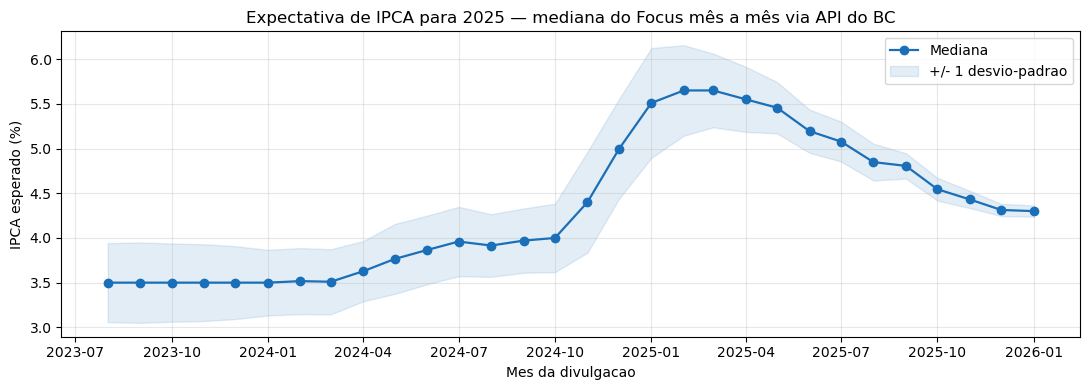

In [5]:
# Grafico temporal: como a expectativa de mercado (mediana do Focus)
# evoluiu mes a mes para o ano de referencia. Cada ponto e um mes coletado.
plt.figure(figsize=(11, 4))
plt.plot(df_focus['mes'], df_focus['Mediana'],
         marker='o', color='#1A6FB8', linewidth=1.6, label='Mediana')
plt.fill_between(df_focus['mes'],
                 df_focus['Mediana'] - df_focus['DesvioPadrao'],
                 df_focus['Mediana'] + df_focus['DesvioPadrao'],
                 color='#1A6FB8', alpha=0.12, label='+/- 1 desvio-padrao')
ano = df_focus['DataReferencia'].iloc[0]
plt.title(f'Expectativa de IPCA para {ano} — mediana do Focus mês a mês via API do BC')
plt.xlabel('Mes da divulgacao'); plt.ylabel('IPCA esperado (%)')
plt.grid(alpha=0.3); plt.legend()
plt.tight_layout()
plt.show()

> **Pare e reflita.** Conseguimos câmbio e expectativas de inflação sem abrir um navegador, sem BeautifulSoup, sem Selenium. **Este é o degrau 1 fazendo seu trabalho.** Se a aula terminasse aqui, já teríamos recuperado dados econômicos reais de forma limpa, estável e legal.>> A pergunta que destrava o resto da aula é: **e quando NÃO existe API?**

---# Degrau 2 — Antes de raspar, procure a porta da frenteComo soubemos que existia API? **Lendo a documentação de dados abertos.** Essa é a habilidade de recuperação mais subestimada. Checklist antes de escrever qualquer scraper:
1. A fonte tem um **portal de dados abertos**? (ex.: `dadosabertos.bcb.gov.br`, `dados.gov.br`)
2. Há **API documentada** ou arquivos para download (CSV/JSON)?
3. Os **termos de uso** permitem o acesso automatizado que você pretende?

Só quando as respostas levam a um beco sem saída é que descemos para o scraping. *Ler a documentação é parte do trabalho — não um passo opcional.*

---
# Degraus 3 e 4 — Quando o scraping se justifica

O **degrau 3** (estatico) foi toda a aula anterior: o conteudo esta no HTML, mas nao ha API.

O **degrau 4** (dinamico) e o nosso foco agora. Ele se justifica quando:
- O conteudo e **renderizado por JavaScript** (nao esta no HTML cru — como a ISO da aula anterior, ou a tabela de cripto que vamos coletar).
- Ou a coleta **exige interacao**: preencher um campo, submeter um formulario, clicar para revelar dados.

Vamos primeiro **provar** que `requests` nao basta, e depois trazer o Selenium para a coleta.

## Configurando o Selenium localmente

O Selenium controla um **navegador de verdade**. Na sua maquina, o navegador (Chrome ou Chromium) **ja esta instalado** — entao nao precisamos baixar nada alem da biblioteca `selenium`. A partir da versao 4.6, o proprio **Selenium Manager** localiza e baixa o driver compativel automaticamente.

Aqui rodamos com **janela visivel** (nao-headless): da para *ver* o navegador abrir, carregar a pagina e ser relido — util didaticamente. Se preferir rodar sem abrir janela, chame `novo_navegador(headless=True)`.

> ### Requisitos para rodar o Selenium localmente
>
> Antes de executar a celula abaixo, confira dois pontos:
>
> - **Navegador da familia Chrome instalado.** O `webdriver.Chrome` precisa do **Google Chrome** ou do **Chromium** na maquina. Se voce so tem Firefox, ou o setup falha, instale um deles — ou troque para o WebDriver do Firefox (`webdriver.Firefox`).
> - **Ambiente grafico (para janela visivel).** Como rodamos com janela visivel, e preciso ter interface grafica — qualquer notebook ou desktop comum tem. Em um servidor *so terminal* (sem tela), use `novo_navegador(headless=True)`, que roda sem abrir janela.
>
> Se algo der errado no setup, o caminho mais robusto e rodar em modo **headless**: a coleta funciona igual, so nao abre a janela.

In [6]:
# === Configuracao do Selenium (ambiente LOCAL) ===
# Basta instalar a biblioteca; o navegador ja existe na sua maquina e o
# Selenium Manager (>= 4.6) resolve o driver compativel sozinho.
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "selenium"], check=True)

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

def novo_navegador(headless=False):
    """Cria um navegador Chrome/Chromium para uso LOCAL.

    headless=False (padrao local): a janela do navegador aparece, e voce
    ve o Selenium agir. Passe headless=True para rodar sem abrir janela.
    """
    opts = webdriver.ChromeOptions()
    if headless:
        opts.add_argument('--headless=new')
    opts.add_argument('--window-size=1280,1024')
    opts.add_argument('user-agent=AulaScraping/1.0 (fins educacionais)')
    return webdriver.Chrome(options=opts)

print('Selenium pronto (modo local, janela visivel).')

Selenium pronto (modo local, janela visivel).


## O conceito mais importante: esperas explícitas

O erro nº 1 de quem começa com Selenium é usar `time.sleep(5)` — uma **espera cega**. Ela ou desperdiça tempo (o elemento já carregou) ou falha (o elemento demorou mais que o previsto).

A forma correta é a **espera explícita**: *“espere até que este elemento específico exista/seja clicável, até um limite.”*
```pythonWebDriverWait(driver, 10).until(    EC.presence_of_element_located((By.CSS_SELECTOR, '#preco')))```

Isso torna o coletor **robusto** — ele se adapta à velocidade real da página, exatamente o que faltava ao `time.sleep`.

## Degrau 4 na pratica: coleta com Selenium no TradingView

Agora o foco e a **coleta com Selenium**. Nosso alvo e a tabela completa do mercado de cripto no TradingView (`prices-all/`): nome, preco, variacao 24h, valor de mercado e volume de dezenas de moedas.

Por que aqui o `requests` nao basta: a pagina e uma **SPA**. A tabela e construida por **JavaScript** depois do carregamento — o HTML cru chega praticamente vazio. Precisamos de um **navegador de verdade** que execute o JavaScript e nos entregue o DOM já renderizado. Esse e o caso clássico do degrau 4.

> **Ética primeiro (faca isto antes de raspar).** Confirme os **Termos de Uso** do site e seu `robots.txt`. A documentacao oficial do Selenium adverte: alguns sites nao permitem automacao e outros ate a bloqueiam. O TradingView permite indexação, mas **restringe coleta automatizada para fins comerciais** e usa proteção anti-bot. Sendo assim, trate o alvo abaixo como ilustração **didática da técnica** — poucas requisições, intervalos folgados, User-Agent honesto — e valide a política vigente antes de qualquer uso real. Para produção, a rota correta seria a **API/feed oficial** da fonte (a própria regra de ouro da nossa escada de recuperação na Web).

In [7]:
# === Coletor real COM SELENIUM: tabela de cripto do TradingView ===
# Diferente de um site estatico (onde requests + read_html bastaria),
# aqui a tabela so existe DEPOIS que o JavaScript roda. Por isso usamos
# Selenium: abrimos um navegador real, esperamos a tabela renderizar
# (espera explicita) e so entao lemos as linhas ja montadas no DOM.

import pandas as pd

URL_CRIPTO_TABELA = 'https://br.tradingview.com/markets/cryptocurrencies/prices-all/'

def coletar_tabela_cripto(top=15):
    """Coleta as primeiras `top` moedas da tabela de cripto via Selenium.

    Retorna um DataFrame com nome, preco e variacao 24h. O ponto central
    da aula esta aqui: NAO e requests -- e um navegador real que executa
    o JavaScript e nos entrega a tabela renderizada.
    """
    driver = novo_navegador()
    try:
        driver.get(URL_CRIPTO_TABELA)

        # ESPERA EXPLICITA: aguardamos as linhas da tabela aparecerem.
        # Sem isso, leriamos a pagina antes do JavaScript montar os dados.
        WebDriverWait(driver, 25).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, 'table tbody tr'))
        )

        linhas = driver.find_elements(By.CSS_SELECTOR, 'table tbody tr')
        registros = []
        for linha in linhas:
            celulas = linha.find_elements(By.CSS_SELECTOR, 'td')
            textos = [c.text.strip() for c in celulas]
            # A 1a celula traz "BTC\nBitcoin"; as seguintes, preco e var%.
            if len(textos) >= 3 and textos[0]:
                nome = textos[0].replace('\n', ' ').strip()
                preco = textos[2] if len(textos) > 2 else ''
                variacao = textos[3] if len(textos) > 3 else ''
                registros.append({'moeda': nome[:28],
                                  'preco': preco,
                                  'var_24h': variacao})
            if len(registros) >= top:
                break
        return pd.DataFrame(registros)
    finally:
        driver.quit()  # sempre fecha o navegador, mesmo se der erro

df_cripto = coletar_tabela_cripto(top=15)
print(f'{len(df_cripto)} moedas coletadas via Selenium (navegador real).')
df_cripto

15 moedas coletadas via Selenium (navegador real).


,moeda,preco,var_24h
0,BTC Bitcoin,"63.357,47 USD","+1,78%"
1,ETH Ethereum,"1.752,88 USD","+0,79%"
2,USDT Tether USDt,"0,99917 USD","+0,00%"
3,BNB BNB,"572,10 USD","+1,26%"
4,USDC USDC,"0,99947 USD","−0,05%"
5,XRP XRP,"1,0972 USD","+0,73%"
6,SOL Solana,"78,175 USD","+1,19%"
7,TRX TRON,"0,33185 USD","+0,71%"
8,HYPE Hyperliquid,"67,728 USD","+0,35%"
9,DOGE Dogecoin,"0,073133 USD","+0,60%"


> ### Pare e reflita — qual degrau o problema exige?
>
> Repare no contraste ao longo da aula:
>
> - No **Banco Central** (cambio e Focus), existia **API oficial**: degrau 1, sem navegador, sem parser de HTML.
> - No **TradingView** (tabela de cripto), o dado só aparece **depois do JavaScript rodar** — o `requests` traria a casca vazia. Foi preciso **Selenium** (degrau 4).
>
> A lição não é *"requests é fraco"* nem *"Selenium e sempre necessário"*. A habilidade central de **recuperação de informação na Web** é **diagnosticar** qual ferramenta o alvo exige:
>
> | Sinal observado | Degrau recomendado |
> |---|---|
> | Existe API documentada (ex.: Banco Central) | **API** — sempre a primeira opção |
> | Sem API, mas o dado já aparece no HTML cru | **requests + parser** (BeautifulSoup / `read_html`) |
> | O dado so aparece após o JavaScript rodar, ou exige interação (preencher, clicar, esperar) | **Selenium** — o último recurso |
>
> Selenium é poderoso, mas é o mais pesado e o mais frágil. Subimos a escada **um degrau de cada vez**, e só escalamos quando o degrau anterior comprovadamente não resolve.

---
# Monitorar um valor ao longo do tempo: três abordagens

Agora a aplicação do caso: **acompanhar a variação de um valor ao longo do tempo.** Vamos monitorar o **preço do Bitcoin no TradingView** — um dado que muda em segundos e que, por ser montado via JavaScript, exige **Selenium** (degrau 4). Ha três formas de monitorar, com trade-offs diferentes.

> **Nota.** Monitorar e um *conceito*, não uma ferramenta. As três abordagens abaixo usam a mesma fonte (Selenium sobre o TradingView); o que muda e a **lógica de registro**: gravar tudo, gravar só o que mudou, ou reler ao vivo. Em todas, reaproveitamos **uma única sessao** de navegador — abrir e fechar o Chrome a cada leitura seria caro e mais detectável.

### Abordagem 1 — Snapshot periodico  ·  degrau 4 (Selenium)

Captura o valor em intervalos fixos e **grava todo o histórico** (timestamp + valor). Simples e completo. Fonte: o preco do Bitcoin lido do TradingView com Selenium, reusando uma sessão de navegador já aberta.

In [8]:
import json
import time
import re
from datetime import datetime

# Monitoramos o preco do Bitcoin no TradingView via Selenium. Como o valor
# e montado por JavaScript, um navegador real e necessario (degrau 4).
# Reaproveitamos UMA sessao de navegador entre as leituras -- mais leve e
# menos detectavel do que reabrir o Chrome toda vez.

URL_BTC = 'https://br.tradingview.com/symbols/BTCUSD/'

def abrir_sessao(url=URL_BTC):
    """Abre o navegador uma vez e carrega a pagina do ativo."""
    driver = novo_navegador()
    driver.get(url)
    # espera a area de cotacao existir antes da primeira leitura
    WebDriverWait(driver, 25).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, 'body'))
    )
    return driver

def ler_preco_btc(driver):
    """Le o preco atual do BTC a partir do DOM ja renderizado.

    A pagina mostra o preco em destaque; procuramos no texto da pagina
    o primeiro numero no formato de cotacao (ex.: 59.585,28). Como o
    JavaScript ja rodou, o valor esta presente no DOM.
    """
    # atualiza a leitura do DOM relendo o texto visivel da pagina
    texto = driver.find_element(By.CSS_SELECTOR, 'body').text
    # padrao de preco: milhar com ponto e decimais com virgula
    m = re.search(r'\b\d{1,3}(?:\.\d{3})*,\d{2,}\b', texto)
    return m.group(0) if m else None

def monitor_snapshot(driver, intervalo_seg=5, n_amostras=4, arquivo=None):
    """Captura o preco a cada `intervalo_seg`, gravando TODO o historico."""
    if arquivo is None:
        arquivo = (PATH + 'historico_btc.jsonl') if 'PATH' in globals() else 'historico_btc.jsonl'
    for i in range(n_amostras):
        valor = ler_preco_btc(driver)
        ts = datetime.now().isoformat(timespec='seconds')
        registro = {'ts': ts, 'btc_usd': valor}
        with open(arquivo, 'a', encoding='utf-8') as f:
            f.write(json.dumps(registro, ensure_ascii=False) + '\n')
        print(f'[{ts}] BTC/USD: {valor}')
        if i < n_amostras - 1:
            time.sleep(intervalo_seg)   # cortesia + rate limiting
            driver.refresh()            # mesma sessao, pagina recarregada
            WebDriverWait(driver, 25).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, 'body'))
            )

print('Abordagem 1 (snapshot periodico, via Selenium no TradingView) pronta.')

Abordagem 1 (snapshot periodico, via Selenium no TradingView) pronta.


In [9]:
# >>> Rodando a Abordagem 1 (4 amostras, 5s de intervalo)
# Abrimos UMA sessao de navegador e a reaproveitamos nas leituras.
# Em poucos segundos o preco pode mudar pouco -- e isso e realista.
# O snapshot grava TUDO, permitindo reconstruir a serie depois.
arquivo_btc = (PATH + 'historico_btc.jsonl') if 'PATH' in globals() else 'historico_btc.jsonl'

driver = abrir_sessao()
try:
    monitor_snapshot(driver, intervalo_seg=5, n_amostras=4, arquivo=arquivo_btc)
finally:
    driver.quit()

print()
print(f'Historico gravado em {arquivo_btc}:')
with open(arquivo_btc, encoding='utf-8') as f:
    print(f.read())

[2026-07-09T15:13:50] BTC/USD: 1,71
[2026-07-09T15:13:57] BTC/USD: 1,72
[2026-07-09T15:14:04] BTC/USD: 1,72
[2026-07-09T15:14:11] BTC/USD: 1,72

Historico gravado em ./dataset_economia_scraping/historico_btc.jsonl:
{"ts": "2026-07-09T15:13:50", "btc_usd": "1,71"}
{"ts": "2026-07-09T15:13:57", "btc_usd": "1,72"}
{"ts": "2026-07-09T15:14:04", "btc_usd": "1,72"}
{"ts": "2026-07-09T15:14:11", "btc_usd": "1,72"}



### Abordagem 2 — Detecção de mudança  ·  degrau 4 (Selenium)

Compara cada leitura com a anterior e **só registra/alerta quando o valor muda**. Muito mais econômico em armazenamento; ideal para alertas (*"avise-me quando o BTC passar de X"*).
Mesma fonte da Abordagem 1 (Selenium no TradingView) — muda só a lógica de registro.

> Observação: em janelas curtas o preço pode não mudar entre duas leituras — e aí o *"(sem mudança)"* e o resultado esperado e didático: a economia da abordagem é justamente não guardar o que não mudou.

In [10]:
def monitor_mudanca(driver, intervalo_seg=5, n_amostras=5):
    """So reporta quando o preco MUDA em relacao a leitura anterior."""
    anterior = None
    for i in range(n_amostras):
        atual = ler_preco_btc(driver)
        ts = datetime.now().isoformat(timespec='seconds')
        if atual != anterior:
            print(f"[{ts}] MUDOU: {anterior} -> {atual}")
            anterior = atual
        else:
            print(f"[{ts}] (sem mudanca: {atual})")
        if i < n_amostras - 1:
            time.sleep(intervalo_seg)
            driver.refresh()
            WebDriverWait(driver, 25).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, 'body'))
            )

print('Abordagem 2 (deteccao de mudanca, via Selenium no TradingView) pronta.')

Abordagem 2 (deteccao de mudanca, via Selenium no TradingView) pronta.


In [11]:
# >>> Rodando a Abordagem 2 (so reporta quando o BTC MUDA)
# Reaproveitamos a mesma sessao. Em janelas curtas e comum ver varios
# "(sem mudanca)" -- e essa e justamente a economia da abordagem.
driver = abrir_sessao()
try:
    monitor_mudanca(driver, intervalo_seg=5, n_amostras=5)
finally:
    driver.quit()

[2026-07-09T15:14:30] MUDOU: None -> 1,75
[2026-07-09T15:14:38] MUDOU: 1,75 -> 1,77
[2026-07-09T15:14:45] MUDOU: 1,77 -> 1,72
[2026-07-09T15:14:52] (sem mudanca: 1,72)
[2026-07-09T15:14:59] MUDOU: 1,72 -> 1,77


### Abordagem 3 — Sessão ao vivo  ·  degrau 4 (Selenium)

Mantem **uma única sessão de navegador aberta** e relê o elemento sem recriar o navegador a cada leitura. É a forma mais fiel para acompanhar em tempo real, mas exige a sessão ativa e é a mais detectável pelo servidor.

Esta abordagem **reaproveita as mesmas funções** das anteriores: `abrir_sessao()` e `ler_preco_btc()`. Muda apenas o que fazemos com a leitura -- aqui, reler ao vivo, sem gravar (Abordagem 1) nem filtrar mudancas (Abordagem 2).

In [12]:
# Abordagem 3 = sessao ao vivo.
#
# A diferenca nao esta na coleta, e na LOGICA de registro: a Abordagem 3
# nao grava historico (como a 1) nem filtra mudancas (como a 2) -- ela
# apenas RELE o valor ao vivo, continuamente, na mesma sessao.

def monitor_ao_vivo(driver, intervalo_seg=3, n_amostras=5):
    """Rele o preco ao vivo na mesma sessao, sem gravar nem filtrar.

    Recebe o `driver` ja aberto (como as abordagens 1 e 2) e reusa
    ler_preco_btc() a cada ciclo. E a forma mais fiel de acompanhamento
    em tempo real -- e a mais detectavel, pois mantem a sessao ativa.
    """
    for i in range(n_amostras):
        valor = ler_preco_btc(driver)
        ts = datetime.now().isoformat(timespec='seconds')
        print(f"[{ts}] ao vivo {i+1}/{n_amostras} -> BTC/USD: {valor}")
        if i < n_amostras - 1:
            time.sleep(intervalo_seg)
            driver.refresh()  # mesma sessao, pagina recarregada
            WebDriverWait(driver, 25).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, 'body'))
            )

print('Abordagem 3 (sessao ao vivo) pronta.')

Abordagem 3 (sessao ao vivo) pronta.


In [13]:
# >>> Rodando a Abordagem 3 (uma sessao so, relendo ao vivo)

driver = abrir_sessao()
try:
    monitor_ao_vivo(driver, intervalo_seg=3, n_amostras=5)
finally:
    driver.quit()

[2026-07-09T15:15:12] ao vivo 1/5 -> BTC/USD: 1,76
[2026-07-09T15:15:17] ao vivo 2/5 -> BTC/USD: 1,77
[2026-07-09T15:15:23] ao vivo 3/5 -> BTC/USD: 1,77
[2026-07-09T15:15:29] ao vivo 4/5 -> BTC/USD: 1,72
[2026-07-09T15:15:35] ao vivo 5/5 -> BTC/USD: 1,77


### Trade-offs das três abordagens

As três usam a **mesma fonte** (Selenium sobre o TradingView, degrau 4) e reaproveitam uma sessão de navegador. O que muda é a **lógica de registro**:

| Abordagem | Logica | Armazenamento | Melhor para |
|---|---|---|---|
| **Snapshot** | grava toda leitura | Alto (tudo) | Reconstruir a série completa |
| **Mudanca** | grava só quando muda | Baixo (so diffs) | Alertas e gatilhos |
| **Ao vivo** | relê continuamente | Variável | Acompanhar preços que mudam em segundos |

**Monitorar é um conceito; a abordagem certa depende do seu objetivo** — reconstruir a série, disparar alertas ou observar ao vivo. E vale a regra de ouro: quando existir **API ou feed oficial** para o mesmo dado (como a do Banco Central no Degrau 1), ela continua sendo a porta da frente, antes do Selenium.

---
# Da recuperação ao uso

A série temporal coletada vira insight: tendência, volatilidade, gatilhos de decisão. Já vimos o **gráfico do dolar** (Degrau 1) e o das **expectativas do Focus**, ambos via API. Abaixo, fechamos o ciclo transformando os dados já recuperados em métricas de leitura rápida — usando o que estiver disponível na sessão.

In [14]:
# Do dado recuperado a metricas de decisao -- sem novos requests.
# Mostramos o resumo do dolar (API, Degrau 1) e, se houver, do historico
# de BTC coletado via Selenium nas abordagens de monitoramento.

if 'df_dolar' in dir() and len(df_dolar):
    d = df_dolar.sort_values('dataHoraCotacao')
    inicio, fim = d['cotacaoVenda'].iloc[0], d['cotacaoVenda'].iloc[-1]
    variacao = (fim / inicio - 1) * 100
    volatilidade = d['cotacaoVenda'].pct_change().std() * 100
    print('Dolar (PTAX venda) — coletado via API no Degrau 1:')
    print(f'  Periodo .........: {d["dataHoraCotacao"].min():%d/%m/%Y} '
          f'a {d["dataHoraCotacao"].max():%d/%m/%Y}')
    print(f'  Variacao no periodo: {variacao:+.2f}%')
    print(f'  Minima / Maxima .: R$ {d["cotacaoVenda"].min():.4f} '
          f'/ R$ {d["cotacaoVenda"].max():.4f}')
    print(f'  Volatilidade diaria (desvio dos retornos): {volatilidade:.2f}%')
else:
    print('Rode a celula do Degrau 1 para popular df_dolar.')

# Se rodou a Abordagem 1, temos um historico de BTC gravado via Selenium.
import os, json as _json
_arq = (PATH + 'historico_btc.jsonl') if 'PATH' in globals() else 'historico_btc.jsonl'
if os.path.exists(_arq):
    with open(_arq, encoding='utf-8') as f:
        regs = [_json.loads(l) for l in f if l.strip()]
    precos = [r['btc_usd'] for r in regs if r.get('btc_usd')]
    if precos:
        print()
        print(f'BTC/USD — {len(precos)} leituras coletadas via Selenium:')
        print(f'  Primeira leitura: {precos[0]}')
        print(f'  Ultima leitura .: {precos[-1]}')

Dolar (PTAX venda) — coletado via API no Degrau 1:
  Periodo .........: 04/06/2025 a 09/07/2026
  Variacao no periodo: -8.88%
  Minima / Maxima .: R$ 4.8973 / R$ 5.6332
  Volatilidade diaria (desvio dos retornos): 0.60%

BTC/USD — 4 leituras coletadas via Selenium:
  Primeira leitura: 1,71
  Ultima leitura .: 1,72


---## Síntese: a escada, agora preenchida

| Degrau | Exemplo desta aula | Resultado |


| **1 — API** | Câmbio e Focus (Olinda/BC) | ✅ Dado limpo, sem scraping |

| **2 — Dados abertos** | Portal `dadosabertos.bcb.gov.br` | ✅ Foi como achamos a API |

| **3 — Estático** | (Aula 1: requests + BeautifulSoup) | ✅ Quando há HTML, sem API |

| **4 — Dinâmico** | Selenium + esperas + monitor | ✅ Só quando os de cima não servem |

**A lição que fica não é “como usar Selenium”. É *quando* usar cada degrau — e quando NÃO usar.**
> Conexão com o curso: nas aulas de YouTube, a API do YouTube era o **degrau 1** — a mesma escada. Recuperação responsável começa sempre pela porta da frente.